# AI-Generated Song Detection — Demo Notebook

This notebook demonstrates two tasks:

| Task | Question | Method |
|------|----------|--------|
| **Task 1 — AI Detection** | Is this track AI-generated? | `ai_detection_score(features)` |
| **Task 2 — Attribution** | Are these two tracks musically related? | `compare_tracks(features_a, features_b)` |

The demo uses real audio files:
- **Human original/remake**: MIPPIA SMP dataset (Jennifer Rush and Céline Dion — The Power of Love)
- **AI-generated**: SONICS dataset (Suno-generated track)

In [ ]:
from importlib import reload
from pathlib import Path

import feature_extractor
import similarity_engine

reload(feature_extractor)
reload(similarity_engine)

from feature_extractor import FeatureExtractor
from similarity_engine import compare_tracks, ai_detection_score

extractor = FeatureExtractor(use_clap=False)

# Demo paths
MIPPIA_DIR = Path('smp_dataset/final_dataset')

PATH_ORIGINAL = MIPPIA_DIR / '5' / 'Jennifer Rush - The Power Of Love _Official Video_ _VOD_.wav'
PATH_REMAKE = MIPPIA_DIR / '5' / 'Céline Dion - The Power Of Love _Official Remastered HD Video_.wav'
PATH_AI = Path('data/sonics/fake_songs/fake_00001_suno_0.mp3')

for path in [PATH_ORIGINAL, PATH_REMAKE, PATH_AI]:
    status = 'OK' if path.exists() else 'NOT FOUND'
    print(f'{status:10s} {path.name}')

✓  Jennifer Rush - The Power Of Love _Official Video_ _VOD_.wav
✓  Céline Dion - The Power Of Love _Official Remastered HD Video_.wav
✓  fake_00001_suno_0.mp3


In [2]:
# ── Feature extraction ────────────────────────────────────────────────────────
print('Extracting features...\n')
feats_original = extractor.extract(str(PATH_ORIGINAL))
feats_remake   = extractor.extract(str(PATH_REMAKE))
feats_ai       = extractor.extract(str(PATH_AI))
print('\nDone.')

Extracting features...

Loading: smp_dataset\final_dataset\5\Jennifer Rush - The Power Of Love _Official Video_ _VOD_.wav
  Duration: 297.4s | Sample rate: 22050Hz
  Created 28 chunks (30s window, 10s hop)
  Processing: 5/28 chunks...
  Processing: 10/28 chunks...
  Processing: 15/28 chunks...
  Processing: 20/28 chunks...
  Processing: 25/28 chunks...
Done! Extracted 28 chunks in total.
Loading: smp_dataset\final_dataset\5\Céline Dion - The Power Of Love _Official Remastered HD Video_.wav
  Duration: 287.5s | Sample rate: 22050Hz
  Created 27 chunks (30s window, 10s hop)
  Processing: 5/27 chunks...
  Processing: 10/27 chunks...
  Processing: 15/27 chunks...
  Processing: 20/27 chunks...
  Processing: 25/27 chunks...
Done! Extracted 27 chunks in total.
Loading: data\sonics\fake_songs\fake_00001_suno_0.mp3
  Duration: 224.0s | Sample rate: 22050Hz
  Created 21 chunks (30s window, 10s hop)
  Processing: 5/21 chunks...
  Processing: 10/21 chunks...
  Processing: 15/21 chunks...
  Process

---
## Task 1 — AI Detection

Estimate whether each track is AI-generated by combining:
- a trained Logistic Regression classifier
- a feature-based heuristic guardrail for strong synthetic artifacts

The most informative artifact in this demo is **spectral flatness**, while **phase discontinuity** and **HNR** act as supporting signals.

In [ ]:
ai_orig = ai_detection_score(feats_original)
ai_remake = ai_detection_score(feats_remake)
ai_ai = ai_detection_score(feats_ai)

print('-' * 78)
print(f'  Track          | AI Score | Interpretation           | Method')
print('-' * 78)
print(f'  Original       |  {ai_orig["ai_score"]:.4f}  | {ai_orig["interpretation"]:24s} | {ai_orig["method"]}')
print(f'  Human Remake   |  {ai_remake["ai_score"]:.4f}  | {ai_remake["interpretation"]:24s} | {ai_remake["method"]}')
print(f'  SONICS (Suno)  |  {ai_ai["ai_score"]:.4f}  | {ai_ai["interpretation"]:24s} | {ai_ai["method"]}')
print('-' * 78)
print()
print('Detector breakdown (trained score | heuristic score | artifact likelihoods):')
for name, res in [('Original', ai_orig), ('Remake', ai_remake), ('SONICS', ai_ai)]:
    components = res.get('component_scores', {})
    feature_scores = res.get('feature_scores', {})
    means = res['track_means']
    trained_score = components.get('trained_classifier', float('nan'))
    heuristic_score = components.get('heuristic', res['ai_score'])
    sf_score = feature_scores.get('spectral_flatness', float('nan'))
    pd_score = feature_scores.get('phase_discontinuity', float('nan'))
    hnr_score = feature_scores.get('hnr', float('nan'))
    print(
        f'  {name:12s} model={trained_score:.4f}  heuristic={heuristic_score:.4f}  '
        f'sf_like={sf_score:.3f}  pd_like={pd_score:.3f}  hnr_like={hnr_score:.3f}  '
        f'sf_mean={means["spectral_flatness"]:.5f}'
    )

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Track          │ AI Score │ Interpretation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Original       │  0.0430  │ Likely human-made
  Human Remake   │  0.0031  │ Likely human-made
  SONICS (Suno)  │  0.2473  │ Likely human-made
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Feature breakdown (spectral_flatness · phase_discontinuity · hnr):
  Original      sf=0.01072 (AI-like=0.01)  pd=1.5706 (AI-like=1.57)
  Remake        sf=0.01928 (AI-like=0.02)  pd=1.5705 (AI-like=1.57)
  SONICS        sf=0.00008 (AI-like=0.00)  pd=1.5730 (AI-like=1.57)


---
## Task 2 — Attribution

Estimate whether two tracks are musically related, rather than only whether they sound broadly similar.

The scoring now rewards consistent global alignment and penalizes accidental local matches.

| Pair | Expected outcome |
|------|------------------|
| Original ↔ Human Remake | High score — same underlying song |
| Original ↔ AI (Suno) | Low score — unrelated track |

In [ ]:
result_remake = compare_tracks(feats_original, feats_remake, verbose=False)
result_ai = compare_tracks(feats_original, feats_ai, verbose=False)

print('-' * 74)
print(f'  Pair                        | Attribution | Interpretation')
print('-' * 74)
print(f'  Original ↔ Human Remake     |   {result_remake["attribution_score"]:.4f}    | {result_remake["interpretation"]}')
print(f'  Original ↔ SONICS AI track  |   {result_ai["attribution_score"]:.4f}    | {result_ai["interpretation"]}')
print('-' * 74)
print()
print('Attribution diagnostics:')
for name, res in [('Original ↔ Human Remake', result_remake), ('Original ↔ SONICS AI', result_ai)]:
    diag = res.get('diagnostics', {})
    print(
        f'  {name:24s} base={diag.get("base_similarity", float("nan")):.3f}  '
        f'order={diag.get("order_consistency", float("nan")):.3f}  '
        f'coverage={diag.get("coverage_ratio", float("nan")):.3f}  '
        f'factor={diag.get("consistency_multiplier", float("nan")):.3f}'
    )

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pair                        │ Attribution │ Interpretation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Original ↔ Human Remake     │   0.7074    │ Likely related tracks — significant similarity detected
  Original ↔ SONICS AI track  │   0.3168    │ Low similarity — likely unrelated tracks
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Visualization

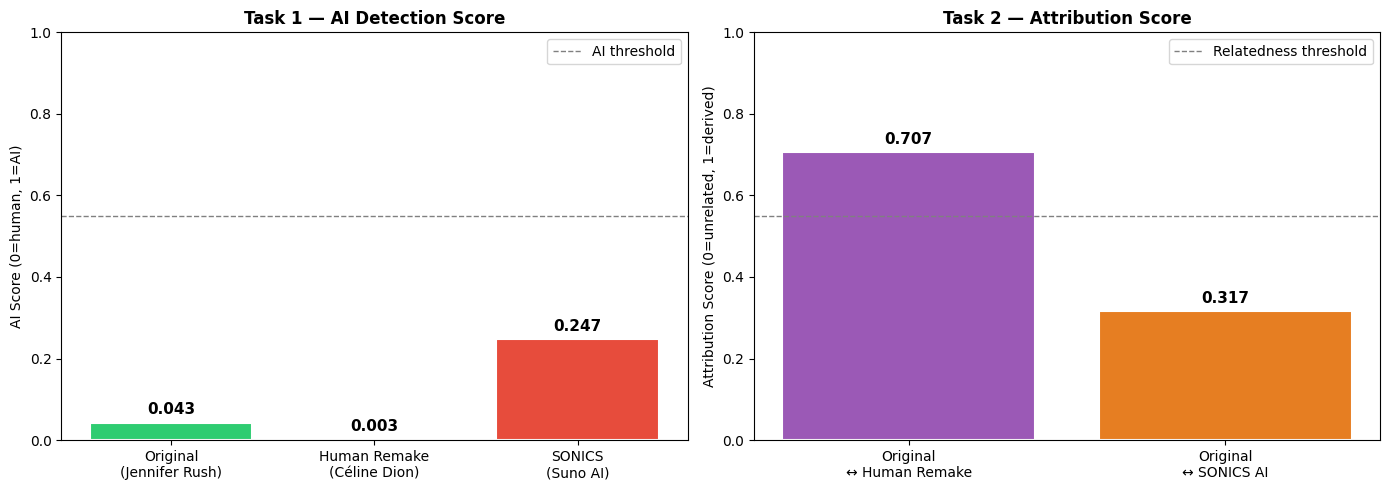

Saved: demo_results.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Task 1: AI detection scores
ax = axes[0]
tracks = ['Original\n(Jennifer Rush)', 'Human Remake\n(Céline Dion)', 'SONICS\n(Suno AI)']
scores = [ai_orig['ai_score'], ai_remake['ai_score'], ai_ai['ai_score']]
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(tracks, scores, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(0.55, color='gray', linestyle='--', linewidth=1, label='AI threshold')
ax.set_ylim(0, 1)
ax.set_title('Task 1 — AI Detection Score', fontweight='bold')
ax.set_ylabel('AI Score (0=human, 1=AI)')
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{score:.3f}',
        ha='center',
        fontsize=11,
        fontweight='bold',
    )
ax.legend()

# Task 2: Attribution scores
ax = axes[1]
pairs = ['Original\n↔ Human Remake', 'Original\n↔ SONICS AI']
ascores = [result_remake['attribution_score'], result_ai['attribution_score']]
colors2 = ['#9b59b6', '#e67e22']
bars2 = ax.bar(pairs, ascores, color=colors2, edgecolor='white', linewidth=1.5)
ax.axhline(0.55, color='gray', linestyle='--', linewidth=1, label='Relatedness threshold')
ax.set_ylim(0, 1)
ax.set_title('Task 2 — Attribution Score', fontweight='bold')
ax.set_ylabel('Attribution Score (0=unrelated, 1=derived)')
for bar, score in zip(bars2, ascores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{score:.3f}',
        ha='center',
        fontsize=11,
        fontweight='bold',
    )
ax.legend()

plt.tight_layout()
plt.savefig('demo_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: demo_results.png')